In [6]:
from sklearn import datasets
digit_dataset = datasets.load_digits()
digit_dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [14]:
digit_dataset["images"].shape

(1797, 8, 8)

In [17]:
digit_dataset["target"] # 정답

array([0, 1, 2, ..., 8, 9, 8])

In [18]:
digit_dataset["images"][0] # 원본 이미지 배열

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [21]:
digit_dataset["images"][1]

array([[ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.],
       [ 0.,  0.,  0., 11., 16.,  9.,  0.,  0.],
       [ 0.,  0.,  3., 15., 16.,  6.,  0.,  0.],
       [ 0.,  7., 15., 16., 16.,  2.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  3.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  6.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  6.,  0.,  0.],
       [ 0.,  0.,  0., 11., 16., 10.,  0.,  0.]])

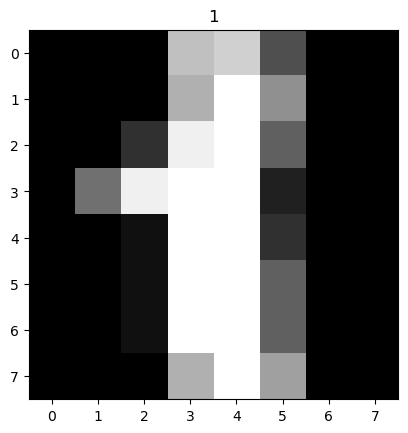

In [33]:
import matplotlib.pyplot as plt

plt.imshow(digit_dataset["images"][1], cmap='gray')
plt.title(digit_dataset["target"][1])
plt.show()

In [37]:
digit_dataset["data"][1] # 1차원으로 변환한 데이터

array([ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.,  0.,  0.,  0., 11., 16.,
        9.,  0.,  0.,  0.,  0.,  3., 15., 16.,  6.,  0.,  0.,  0.,  7.,
       15., 16., 16.,  2.,  0.,  0.,  0.,  0.,  1., 16., 16.,  3.,  0.,
        0.,  0.,  0.,  1., 16., 16.,  6.,  0.,  0.,  0.,  0.,  1., 16.,
       16.,  6.,  0.,  0.,  0.,  0.,  0., 11., 16., 10.,  0.,  0.])

In [38]:
digit_dataset["data"][1].shape

(64,)

In [39]:
from sklearn.model_selection import train_test_split

X = digit_dataset["data"]
y = digit_dataset["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y)#default: test_size=0.25
X_train.shape , X_test.shape

((1347, 64), (450, 64))

In [40]:
from sklearn.linear_model import LogisticRegression

ovr = LogisticRegression(multi_class="ovr") # 시그모이드 함수 사용, 가중치 z 필요
sm = LogisticRegression(multi_class="multinomial", solver="sag") # 소프트맥스 함수 사용, 가중치 z 필요

In [41]:
ovr.fit(X_train, y_train) # z에 쓸 가중치 구함
sm.fit(X_train, y_train) # 가중치 행렬 구함

C:\Users\KBS\anaconda3\envs\ml\lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\KBS\anaconda3\envs\ml\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\KBS\anaconda3\envs\ml\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. F

LogisticRegression(multi_class='multinomial', solver='sag')

In [43]:
y1 = ovr.predict(X_test)
y2 = sm.predict(X_test)

In [44]:
y1[:5]

array([7, 4, 3, 1, 0])

In [45]:
y2[:5]

array([7, 4, 3, 1, 0])

In [46]:
y_test[:5]

array([7, 4, 3, 1, 0])

In [48]:
from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test, y1) # 순서 중요, 첫 번째 실제값, 두 번째 예측값
cm2 = confusion_matrix(y_test, y2)

print(cm1)
print(cm2)

[[35  0  0  0  0  0  0  0  0  0]
 [ 0 43  0  0  0  0  0  0  1  0]
 [ 0  0 41  0  0  0  0  0  0  0]
 [ 0  0  0 43  0  1  0  0  0  1]
 [ 0  1  0  0 46  0  0  1  0  1]
 [ 0  1  0  0  0 37  0  0  0  2]
 [ 0  0  0  0  0  0 45  0  0  0]
 [ 0  1  0  0  0  0  0 44  0  0]
 [ 0  5  0  2  0  0  0  0 46  0]
 [ 0  2  0  0  0  0  0  0  1 50]]
[[35  0  0  0  0  0  0  0  0  0]
 [ 0 44  0  0  0  0  0  0  0  0]
 [ 0  0 41  0  0  0  0  0  0  0]
 [ 0  0  1 42  0  1  0  0  0  1]
 [ 0  1  0  0 47  0  0  1  0  0]
 [ 0  0  0  1  1 35  0  0  1  2]
 [ 0  0  0  0  0  0 45  0  0  0]
 [ 0  0  0  0  0  0  0 45  0  0]
 [ 0  5  0  0  0  1  1  0 45  1]
 [ 0  0  0  0  0  0  0  0  0 53]]


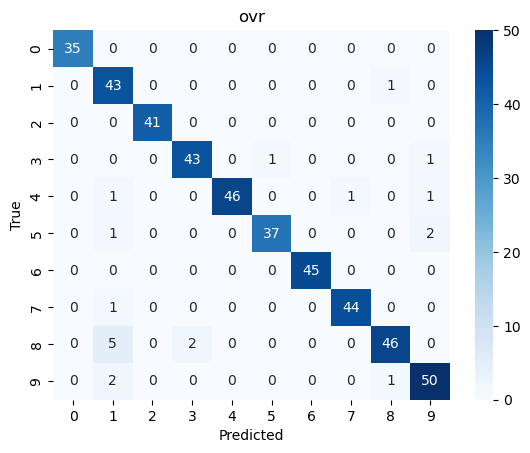

In [53]:
import seaborn as sns

sns.heatmap(cm1, annot=True, cmap='Blues')
plt.title("ovr")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

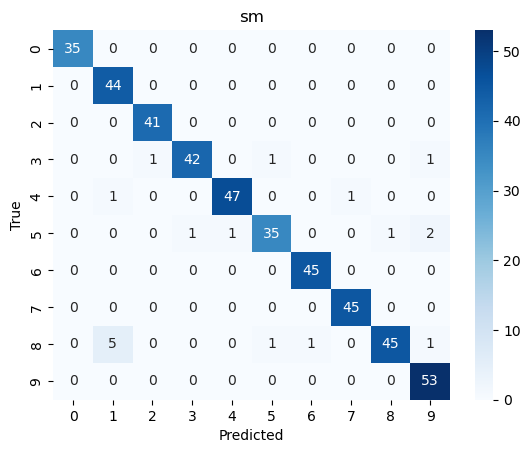

In [54]:
sns.heatmap(cm2, annot=True, cmap='Blues')
plt.title("sm")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y1))
print(classification_report(y_test, y2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.81      0.98      0.89        44
           2       1.00      1.00      1.00        41
           3       0.96      0.96      0.96        45
           4       1.00      0.94      0.97        49
           5       0.97      0.93      0.95        40
           6       1.00      1.00      1.00        45
           7       0.98      0.98      0.98        45
           8       0.96      0.87      0.91        53
           9       0.93      0.94      0.93        53

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.88      1.00      0.94        44
           2       0.98      1.00      0.99        41
           3       0.98 

In [58]:
import pandas as pd

y_bin = pd.get_dummies(y_test).values#실제값을 one-hot 형태로 변환
y_bin[:5]

array([[False, False, False, False, False, False, False,  True, False,
        False],
       [False, False, False, False,  True, False, False, False, False,
        False],
       [False, False, False,  True, False, False, False, False, False,
        False],
       [False,  True, False, False, False, False, False, False, False,
        False],
       [ True, False, False, False, False, False, False, False, False,
        False]])

In [63]:
y2_proba = sm.predict_proba(X_test)
y2_proba[:5] # 각 정답일 확률

array([[8.11484746e-13, 2.70119881e-08, 9.43328664e-08, 1.33891509e-11,
        1.67736063e-08, 2.02472562e-07, 2.74926190e-12, 9.99998745e-01,
        5.37475821e-08, 8.60780868e-07],
       [9.29709908e-13, 6.56630432e-06, 2.12060882e-17, 5.60932478e-13,
        9.99991176e-01, 3.44524648e-13, 1.48891079e-06, 1.75729233e-08,
        7.51634061e-07, 1.09271295e-13],
       [1.11911853e-14, 1.21666927e-13, 3.72422858e-09, 9.99999945e-01,
        5.17788408e-15, 2.22498065e-10, 3.66945879e-13, 1.29964902e-11,
        4.71653060e-08, 3.39823536e-09],
       [3.65995169e-16, 9.80839796e-01, 9.48907577e-07, 1.91528632e-02,
        4.36222161e-12, 9.18207175e-12, 1.43381793e-07, 8.13245928e-12,
        4.56610145e-06, 1.68210305e-06],
       [9.99994089e-01, 2.92836012e-12, 5.68887823e-12, 3.01803425e-12,
        1.42828468e-10, 2.27066585e-08, 5.86991415e-06, 6.86919480e-12,
        1.26474123e-08, 5.75644398e-09]])

In [64]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thsh =roc_curve(y_bin[:, 8], y2_proba[:, 8])
area = auc(fpr, tpr)

print(fpr, tpr, thsh)
print(area)

[0.         0.         0.         0.00755668 0.00755668 0.01259446
 0.01259446 0.02518892 0.02518892 0.04030227 0.04030227 0.17128463
 0.17128463 1.        ] [0.         0.01886792 0.86792453 0.86792453 0.9245283  0.9245283
 0.94339623 0.94339623 0.96226415 0.96226415 0.98113208 0.98113208
 1.         1.        ] [           inf 9.99999966e-01 4.79237118e-01 3.45606079e-01
 2.32213576e-01 1.78328676e-01 1.67535432e-01 1.10480983e-01
 7.58695535e-02 1.23412819e-02 1.11959527e-02 2.92232448e-04
 2.86027275e-04 8.18623660e-15]
0.9948671641081697
